In [1]:
import numpy as np

import torch
import torch.optim as optim
import torch.nn as nn
import torch.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, auc
from stepbystep.v0 import StepByStep

# Data Generation

In [2]:
X, y = make_moons(n_samples=100, noise=0.3, random_state=0)

In [3]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=.2, random_state=13)

In [4]:
sc = StandardScaler()
sc.fit(X_train)

X_train = sc.transform(X_train)
X_val = sc.transform(X_val)

In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def figure1(X_train, y_train, X_val, y_val, cm_bright=None):
    if cm_bright is None:
        cm_bright = ListedColormap(['#FF0000', '#0000FF'])

    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright)
    ax[0].set_xlabel(r'$X_1$')
    ax[0].set_ylabel(r'$X_2$')
    ax[0].set_xlim([-2.3, 2.3])
    ax[0].set_ylim([-2.3, 2.3])
    ax[0].set_title('Generated Data - Train')

    ax[1].scatter(X_val[:, 0], X_val[:, 1], c=y_val, cmap=cm_bright)
    ax[1].set_xlabel(r'$X_1$')
    ax[1].set_ylabel(r'$X_2$')
    ax[1].set_xlim([-2.3, 2.3])
    ax[1].set_ylim([-2.3, 2.3])
    ax[1].set_title('Generated Data - Validation')
    fig.tight_layout()
    plt.show()

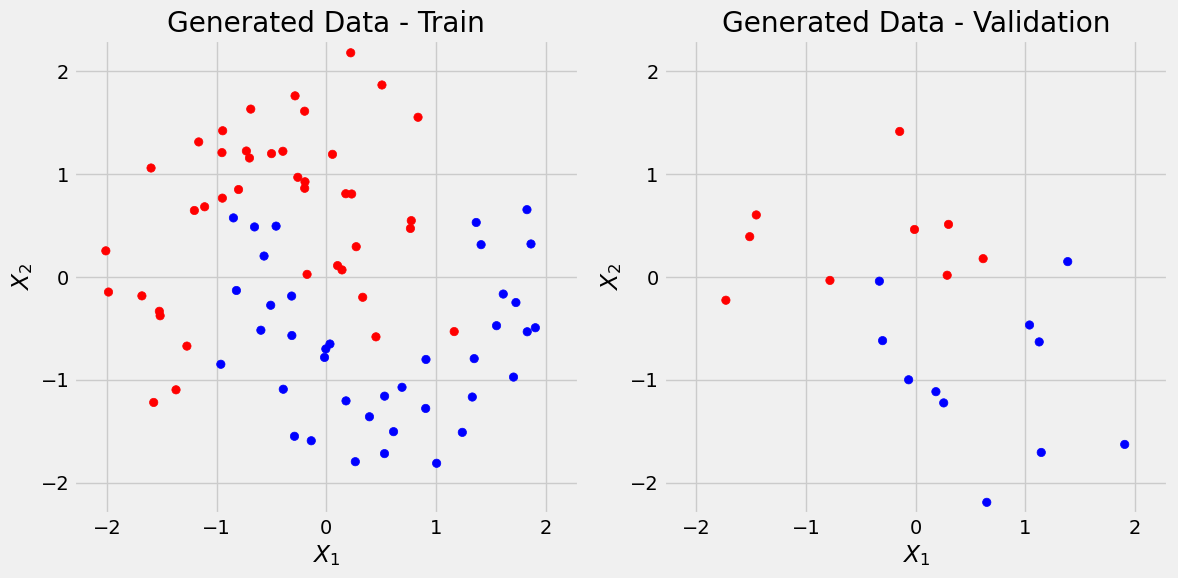

In [6]:
figure1(X_train, y_train, X_val, y_val)

# Data Preparation

In [7]:
torch.manual_seed(13)

# build tensors from Numpy arrays
x_train_tensor = torch.as_tensor(X_train).float()
y_train_tensor = torch.as_tensor(y_train.reshape(-1, 1)).float()

x_val_tensor = torch.as_tensor(X_val).float()
y_val_tensor = torch.as_tensor(y_val.reshape(-1, 1)).float()

# builds dataset containing all data points
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)

# builds a loader of each set
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=16,
    shuffle=True
)
val_loader = DataLoader(dataset=val_dataset, batch_size=16)

In [8]:
def odd_ratio(prob):
    return prob / (1 - prob)

p = .75
q = 1 - p
odd_ratio(p), odd_ratio(q)

(3.0, 0.3333333333333333)

In [9]:
def figure2(prob1):
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    prob = np.linspace(.01, .99, 99)
    for i in [0, 1]:
        ax[i].plot(prob, odd_ratio(prob), linewidth=2)
        ax[i].set_xlabel('Probability')
        if i:
            ax[i].set_yscale('log')
            ax[i].set_ylabel('Odds Ratio (log scale)')
            ax[i].set_title('Odds Ratio (log scale)')
        else:
            ax[i].set_ylabel('Odds Ratio')
            ax[i].set_title('Odds Ratio')
        ax[i].scatter([prob1, .5, (1 - prob1)], [odd_ratio(prob1), odd_ratio(.5), odd_ratio(1 - prob1)], c='r')
    fig.tight_layout()
    return fig

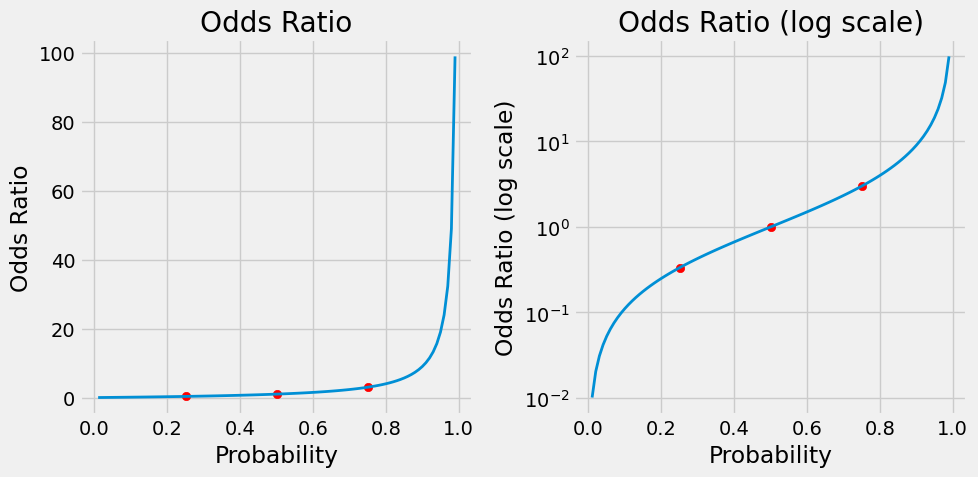

In [10]:
fig = figure2(p)

In [11]:
def log_odds_ratio(prob):
    return np.log(odd_ratio(prob))
p = .75
q = 1 - p
log_odds_ratio(p), log_odds_ratio(q)

(np.float64(1.0986122886681098), np.float64(-1.0986122886681098))

In [12]:
def figure3(prob1):
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    prob = np.linspace(.01, .99, 99)

    ax[0].plot(prob, log_odds_ratio(prob), linewidth=2)
    ax[0].set_xlabel('Probability')
    ax[0].set_ylabel('Log Odds Ratio')
    ax[0].set_title('Log Odds Ratio')
    ax[0].scatter([prob1, .5, (1-prob1)], [log_odds_ratio(prob1), log_odds_ratio(.5), log_odds_ratio(1-prob1)], c='r')
    
    ax[1].plot(log_odds_ratio(prob), prob, linewidth=2)
    ax[1].set_xlabel('Probability')
    ax[1].set_ylabel('Log Odds Ratio')
    ax[1].set_title('Probability')
    ax[1].scatter([log_odds_ratio(prob1), log_odds_ratio(.5), log_odds_ratio(1-prob1)], [prob1, .5, (1-prob1)], c='r')

    return fig

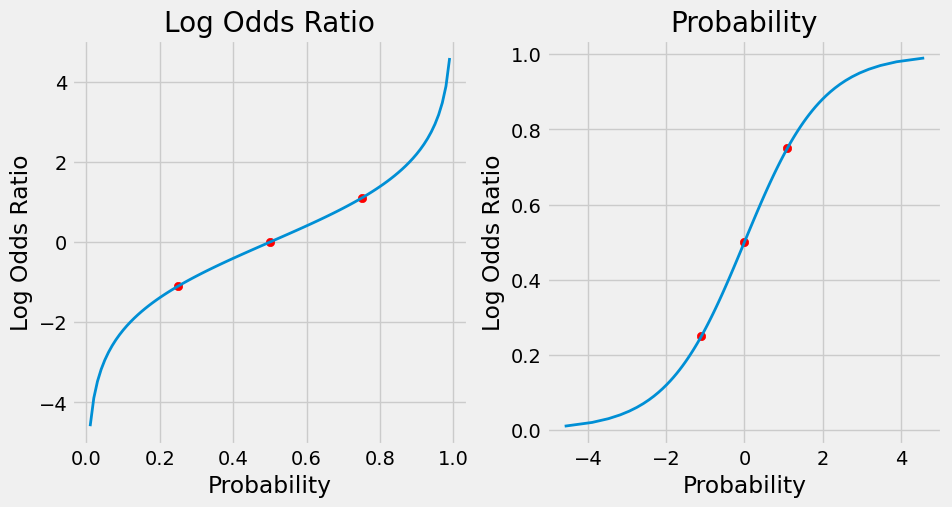

In [13]:
fig = figure3(p)

In [14]:
# sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

p = .75
q = 1 - p
sigmoid(log_odds_ratio(p)), sigmoid(log_odds_ratio(q))

(np.float64(0.75), np.float64(0.25))

In [15]:
torch.sigmoid(torch.tensor(1.0986)), torch.sigmoid(torch.tensor(-1.0986))

(tensor(0.7500), tensor(0.2500))

In [16]:
def figure4(prob1):
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    prob = np.linspace(.01, .99, 99)

    ax.plot(log_odds_ratio(prob), prob, linewidth=2, c='r')
    ax.set_ylabel('Probability')
    ax.set_xlabel('Log Odds Ratio')
    ax.set_title('Sigmoid')
    ax.scatter([log_odds_ratio(prob1), log_odds_ratio(.5), log_odds_ratio(1-prob1)], [prob1, .5, (1-prob1)], c='r')
    fig.tight_layout()
    return fig


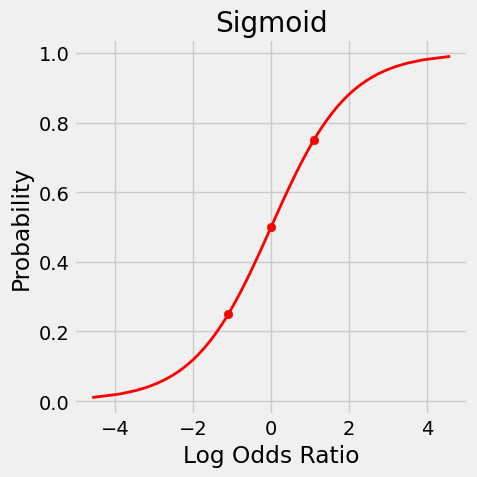

In [17]:
fig = figure4(p)

In [18]:
torch.manual_seed(42)
model1 = nn.Sequential()
model1.add_module('linear', nn.Linear(2, 1))
model1.add_module('sigmoid', nn.Sigmoid())
print(model1.state_dict())

OrderedDict([('linear.weight', tensor([[0.5406, 0.5869]])), ('linear.bias', tensor([-0.1657]))])


## Loss

In [19]:
dummy_labels = torch.tensor([1.0, 0.0])
dummy_predictions = torch.tensor([.9, .2])

# positive class (labels == 1)
positive_pred = dummy_predictions[dummy_labels == 1]
first_summation = torch.log(positive_pred).sum()
# negative class (labels == 0)
negative_pred = dummy_predictions[dummy_labels == 0]
second_summation = torch.log(1 - negative_pred).sum()
# n_total = n_pos + n_neg
n_total = dummy_labels.size(0)

loss = -(first_summation + second_summation) / n_total
loss

tensor(0.1643)

In [20]:
summation = torch.sum(
    dummy_labels * torch.log(dummy_predictions) + (1 - dummy_labels) * torch.log(1 - dummy_predictions)
)
loss = - summation / n_total
loss

tensor(0.1643)

## BCELoss

In [21]:
loss_fn = nn.BCELoss(reduction='mean')
loss_fn

BCELoss()

In [22]:
dummy_labels = torch.tensor([1.0, 0.0])
dummy_predictions = torch.tensor([.9, .2])

right_loss = loss_fn(dummy_predictions, dummy_labels)
wrong_loss = loss_fn(dummy_labels, dummy_predictions)

print(right_loss, wrong_loss)

tensor(0.1643) tensor(15.0000)


## BCEWithLogitsLoss

In [23]:
loss_fn_logits = nn.BCEWithLogitsLoss(reduction='mean')
loss_fn_logits

BCEWithLogitsLoss()

In [24]:
logit1 = log_odds_ratio(.9)
logit2 = log_odds_ratio(.2)
dummy_labels = torch.tensor([1.0, 0.0])
dummy_logits = torch.tensor([logit1, logit2])
print(dummy_logits)

tensor([ 2.1972, -1.3863], dtype=torch.float64)


## Imbalanced Dataset

In [25]:
dummy_imb_labels = torch.tensor([1.0, 0.0, 0.0, 0.0])
dummy_imb_logits = torch.tensor([logit1, logit2, logit2, logit2])

In [26]:
n_neg = (dummy_imb_labels == 0).sum().float()
n_pos = (dummy_imb_labels == 1).sum().float()

pos_weight = (n_neg / n_pos).view(1,)
pos_weight

tensor([3.])

In [27]:
loss_fn_imb = nn.BCEWithLogitsLoss(
    reduction='mean',
    pos_weight=pos_weight
)

In [28]:
loss = loss_fn_imb(dummy_imb_logits, dummy_imb_labels)
loss

tensor(0.2464)

In [29]:
loss_fn_imb_sum = nn.BCEWithLogitsLoss(
    reduction='sum',
    pos_weight=pos_weight
)
loss = loss_fn_imb_sum(dummy_imb_logits, dummy_imb_labels)
loss = loss / (pos_weight * n_pos + n_neg)
loss

tensor([0.1643])

In [30]:
# model congiguration
lr = 0.1
torch.manual_seed(42)
model = nn.Sequential()
model.add_module('linear', nn.Linear(2, 1))
optimizer = optim.SGD(model.parameters(), lr=lr)
loss_fn = nn.BCEWithLogitsLoss()

In [31]:
# model training
n_epochs = 100

sbs = StepByStep(model, loss_fn, optimizer)
sbs.set_loaders(train_loader, val_loader)
sbs.train(n_epochs)

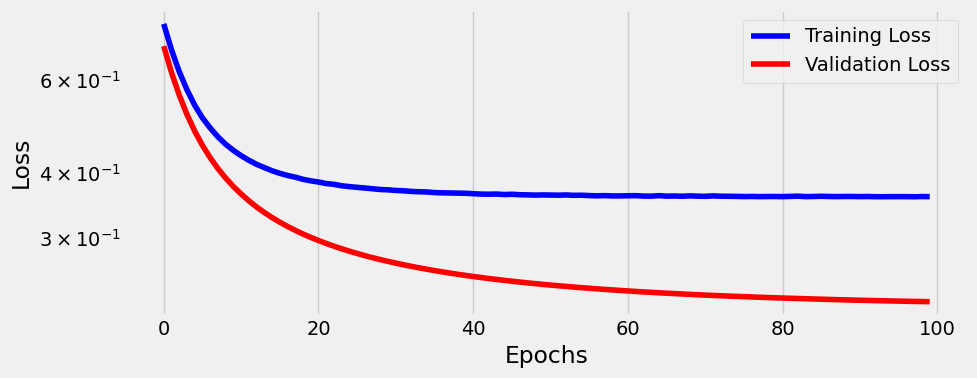

In [32]:
fig = sbs.plot_losses()

In [33]:
print(model.state_dict())

OrderedDict([('linear.weight', tensor([[ 1.1806, -1.8693]])), ('linear.bias', tensor([-0.0591]))])


In [34]:
predictions = sbs.predict(x_train_tensor[:4])
predictions

array([[ 0.20345592],
       [ 2.9444451 ],
       [ 3.6933174 ],
       [-1.2334073 ]], dtype=float32)

In [35]:
probabilities = sigmoid(predictions)
probabilities

array([[0.5506892 ],
       [0.9500003 ],
       [0.9757151 ],
       [0.22558564]], dtype=float32)

In [36]:
classes = (predictions >= 0).astype(int)
classes

array([[1],
       [1],
       [1],
       [0]])

## Decision Boundary

In [37]:
model = nn.Sequential()
model.add_module('hidden', nn.Linear(2, 10))
model.add_module('activation', nn.ReLU())
model.add_module('output', nn.Linear(10, 1))
model.add_module('sigmoid', nn.Sigmoid())

loss_fn = nn.BCELoss()

In [39]:
logits_val = sbs.predict(X_val)
probabilities = sigmoid(logits_val).squeeze()
probabilities

array([0.40727955, 0.67678314, 0.0704309 , 0.28166208, 0.15684399,
       0.7853204 , 0.58240235, 0.991824  , 0.9946826 , 0.28467533,
       0.8495085 , 0.561342  , 0.9887806 , 0.05197177, 0.90380603,
       0.92610323, 0.05332584, 0.9204765 , 0.8846582 , 0.34013632],
      dtype=float32)

## confusion matrix

In [40]:
cm_thresh50 = confusion_matrix(y_val, (probabilities >= 0.5))
cm_thresh50

array([[ 7,  2],
       [ 1, 10]])

In [44]:
def split_cm(cm):
    # actual negative go to in the top row, above probabilty line
    actual_negative = cm[0]
    # predicted negatives go in the first column
    tn = actual_negative[0]
    # predicted postives go in the second column
    fp = actual_negative[1]
    # actual positives go in the bottom row, below probability line
    actual_positive = cm[1]
    # predicted negative go in the first column
    fn = actual_positive[0]
    # predicted positive go in the second column
    tp = actual_positive[1]
    return tn, fp, fn, tp

In [45]:
def tpr_fpr(cm):
    tn, fp, fn, tp = split_cm(cm)
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)
    return tpr, fpr

In [46]:
tpr_fpr(cm_thresh50)

(np.float64(0.9090909090909091), np.float64(0.2222222222222222))

In [59]:
def precision_recall(cm):
    tn, fp, fn, tp = split_cm(cm)

    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    return precision, recall

In [60]:
precision_recall(cm_thresh50)

(np.float64(0.8333333333333334), np.float64(0.9090909090909091))

In [61]:
confusion_matrix(y_val, (probabilities >= 0.3))

array([[ 6,  3],
       [ 0, 11]])

In [62]:
confusion_matrix(y_val, (probabilities >= 0.7))

array([[9, 0],
       [2, 9]])

In [63]:
threshs = np.linspace(0, 1, 11)
threshs

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [73]:
def eval_curves(fprs, tprs, recalls, precisions, thresholds, thresholds2=None, line=False, annot=False):
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    
    if thresholds2 is None:
        thresholds2 = thresholds[:]

    marker = '.r-' if line else '.r'
    
    axs[0].plot(fprs, tprs, marker, markersize=12, linewidth=2)
    axs[0].set_xlim([-.05, 1.05])
    axs[0].set_ylim([-.05, 1.05])
    axs[0].set_xlabel('False Positive Rate')
    axs[0].set_ylabel('True Positive Rate')
    axs[0].set_title('ROC Curve')

    axs[1].plot(recalls, precisions, marker, markersize=12, linewidth=2)
    axs[1].set_xlim([-.05, 1.05])
    axs[1].set_ylim([-.05, 1.05])
    axs[1].set_xlabel('Recall')
    axs[1].set_ylabel('Precision')
    axs[1].set_title('Precision-Recall Curve')
    
    if annot:
        for thresh, fpr, tpr, prec, rec in zip(thresholds, fprs, tprs, precisions, recalls):
            axs[0].annotate(str(thresh), xy=(fpr - .03, tpr - .07))
            
        for thresh, fpr, tpr, prec, rec in zip(thresholds2, fprs, tprs, precisions, recalls):
            axs[1].annotate(str(thresh), xy=(rec - .03, prec - .07))

    fig.tight_layout()
    plt.show()

def figure17(y, probabilities, threshs):
    cms = [confusion_matrix(y, (probabilities >= threshold)) for threshold in threshs]
    rates = np.array(list(map(tpr_fpr, cms)))
    prerec = np.array(list(map(precision_recall, cms)))
    fig = eval_curves(rates[:, 1], rates[:, 0], prerec[:, 1], prerec[:, 0], threshs, line=True, annot=False)
    return fig

/var/folders/8n/4tmx7gjx57j_gn5wps411qp40000gn/T/ipykernel_11146/2145847065.py:4: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


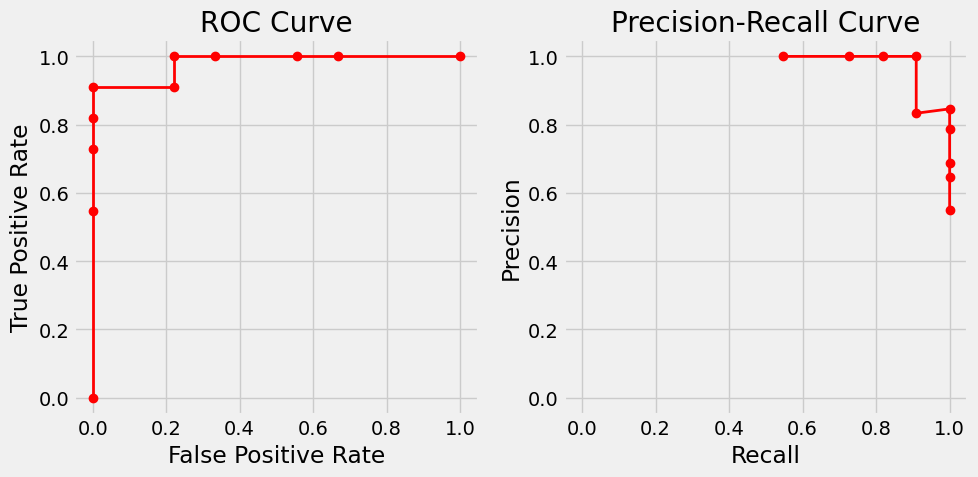

In [74]:
fig = figure17(y_val, probabilities, threshs)

In [75]:
fpr, tpr, threshold1 = roc_curve(y_val, probabilities)
prec, rec, threshold2 = precision_recall_curve(y_val, probabilities)

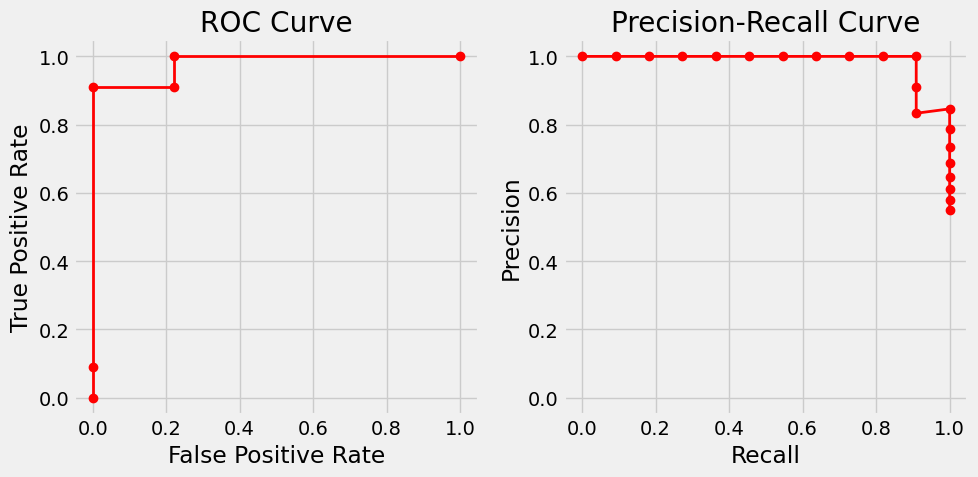

In [76]:
fig = eval_curves(fpr, tpr, rec, prec, threshold1, threshold2, line=True)

In [77]:
np.random.seed(39)
random_probs = np.random.uniform(size=y_val.shape)
fpr_random, tpr_random, thresholds1_random = roc_curve(y_val, random_probs)
prec_random, rec_random, thresholds2_random = precision_recall_curve(y_val, random_probs)

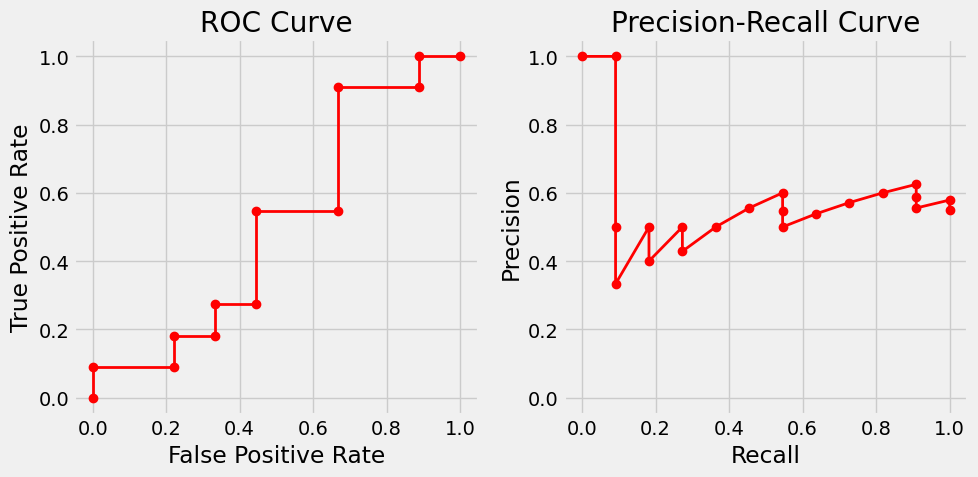

In [78]:
eval_curves(fpr_random, tpr_random, rec_random, prec_random, thresholds1_random, thresholds2_random, line=True)

In [79]:
auroc = auc(fpr, tpr)
aupr = auc(rec, prec)
print(auroc, aupr)

0.9797979797979798 0.9854312354312356


In [80]:
# area under the curves of the random model
auroc_random = auc(fpr_random, tpr_random)
aupr_random = auc(rec_random, prec_random)
print(auroc_random, aupr_random)

0.505050505050505 0.570559046216941
